<a href="https://colab.research.google.com/github/tirupari57/AI-Course/blob/AI%2FML-Course/Credit_EDA_assignment_Approach.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# Filtering out the warnings

import warnings

warnings.filterwarnings('ignore')

In [6]:
# Importing the required libraries

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [7]:
df = pd.read_csv('applicationdata.csv')


df.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [8]:
df.shape # (307511, 122)
df.info() # rows,columns, datatypes,mem storage
df.describe() #The difference (122 - 106 = 16 columns) indicates that there are 16 non-numerical columns in your df DataFrame for which describe() does not provide these specific statistics.


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 122 entries, SK_ID_CURR to AMT_REQ_CREDIT_BUREAU_YEAR
dtypes: float64(65), int64(41), object(16)
memory usage: 286.2+ MB


,SK_ID_CURR,TARGET,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
count,307511.000000,307511.000000,307511.000000,3.075110e+05,3.075110e+05,307499.000000,3.072330e+05,307511.000000,307511.000000,307511.000000,...,307511.000000,307511.000000,307511.000000,307511.000000,265992.000000,265992.000000,265992.000000,265992.000000,265992.000000,265992.000000
mean,278180.518577,0.080729,0.417052,1.687979e+05,5.990260e+05,27108.573909,5.383962e+05,0.020868,-16036.995067,63815.045904,...,0.008130,0.000595,0.000507,0.000335,0.006402,0.007000,0.034362,0.267395,0.265474,1.899974
std,102790.175348,0.272419,0.722121,2.371231e+05,4.024908e+05,14493.737315,3.694465e+05,0.013831,4363.988632,141275.766519,...,0.089798,0.024387,0.022518,0.018299,0.083849,0.110757,0.204685,0.916002,0.794056,1.869295
min,100002.000000,0.000000,0.000000,2.565000e+04,4.500000e+04,1615.500000,4.050000e+04,0.000290,-25229.000000,-17912.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,189145.500000,0.000000,0.000000,1.125000e+05,2.700000e+05,16524.000000,2.385000e+05,0.010006,-19682.000000,-2760.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,278202.000000,0.000000,0.000000,1.471500e+05,5.135310e+05,24903.000000,4.500000e+05,0.018850,-15750.000000,-1213.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
75%,367142.500000,0.000000,1.000000,2.025000e+05,8.086500e+05,34596.000000,6.795000e+05,0.028663,-12413.000000,-289.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000
max,456255.000000,1.000000,19.000000,1.170000e+08,4.050000e+06,258025.500000,4.050000e+06,0.072508,-7489.000000,365243.000000,...,1.000000,1.000000,1.000000,1.000000,4.000000,9.000000,8.000000,27.000000,261.000000,25.000000


In [9]:
df2 = pd.read_csv('previousapplication.csv')
df2.shape
df2.info()
df2.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1670214 entries, 0 to 1670213
Data columns (total 37 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   SK_ID_PREV                   1670214 non-null  int64  
 1   SK_ID_CURR                   1670214 non-null  int64  
 2   NAME_CONTRACT_TYPE           1670214 non-null  object 
 3   AMT_ANNUITY                  1297979 non-null  float64
 4   AMT_APPLICATION              1670214 non-null  float64
 5   AMT_CREDIT                   1670213 non-null  float64
 6   AMT_DOWN_PAYMENT             774370 non-null   float64
 7   AMT_GOODS_PRICE              1284699 non-null  float64
 8   WEEKDAY_APPR_PROCESS_START   1670214 non-null  object 
 9   HOUR_APPR_PROCESS_START      1670214 non-null  int64  
 10  FLAG_LAST_APPL_PER_CONTRACT  1670214 non-null  object 
 11  NFLAG_LAST_APPL_IN_DAY       1670214 non-null  int64  
 12  RATE_DOWN_PAYMENT            774370 non-nu

,SK_ID_PREV,SK_ID_CURR,AMT_ANNUITY,AMT_APPLICATION,AMT_CREDIT,AMT_DOWN_PAYMENT,AMT_GOODS_PRICE,HOUR_APPR_PROCESS_START,NFLAG_LAST_APPL_IN_DAY,RATE_DOWN_PAYMENT,...,RATE_INTEREST_PRIVILEGED,DAYS_DECISION,SELLERPLACE_AREA,CNT_PAYMENT,DAYS_FIRST_DRAWING,DAYS_FIRST_DUE,DAYS_LAST_DUE_1ST_VERSION,DAYS_LAST_DUE,DAYS_TERMINATION,NFLAG_INSURED_ON_APPROVAL
count,1.670214e+06,1.670214e+06,1.297979e+06,1.670214e+06,1.670213e+06,7.743700e+05,1.284699e+06,1.670214e+06,1.670214e+06,774370.000000,...,5951.000000,1.670214e+06,1.670214e+06,1.297984e+06,997149.000000,997149.000000,997149.000000,997149.000000,997149.000000,997149.000000
mean,1.923089e+06,2.783572e+05,1.595512e+04,1.752339e+05,1.961140e+05,6.697402e+03,2.278473e+05,1.248418e+01,9.964675e-01,0.079637,...,0.773503,-8.806797e+02,3.139511e+02,1.605408e+01,342209.855039,13826.269337,33767.774054,76582.403064,81992.343838,0.332570
std,5.325980e+05,1.028148e+05,1.478214e+04,2.927798e+05,3.185746e+05,2.092150e+04,3.153966e+05,3.334028e+00,5.932963e-02,0.107823,...,0.100879,7.790997e+02,7.127443e+03,1.456729e+01,88916.115834,72444.869708,106857.034789,149647.415123,153303.516729,0.471134
min,1.000001e+06,1.000010e+05,0.000000e+00,0.000000e+00,0.000000e+00,-9.000000e-01,0.000000e+00,0.000000e+00,0.000000e+00,-0.000015,...,0.373150,-2.922000e+03,-1.000000e+00,0.000000e+00,-2922.000000,-2892.000000,-2801.000000,-2889.000000,-2874.000000,0.000000
25%,1.461857e+06,1.893290e+05,6.321780e+03,1.872000e+04,2.416050e+04,0.000000e+00,5.084100e+04,1.000000e+01,1.000000e+00,0.000000,...,0.715645,-1.300000e+03,-1.000000e+00,6.000000e+00,365243.000000,-1628.000000,-1242.000000,-1314.000000,-1270.000000,0.000000
50%,1.923110e+06,2.787145e+05,1.125000e+04,7.104600e+04,8.054100e+04,1.638000e+03,1.123200e+05,1.200000e+01,1.000000e+00,0.051605,...,0.835095,-5.810000e+02,3.000000e+00,1.200000e+01,365243.000000,-831.000000,-361.000000,-537.000000,-499.000000,0.000000
75%,2.384280e+06,3.675140e+05,2.065842e+04,1.803600e+05,2.164185e+05,7.740000e+03,2.340000e+05,1.500000e+01,1.000000e+00,0.108909,...,0.852537,-2.800000e+02,8.200000e+01,2.400000e+01,365243.000000,-411.000000,129.000000,-74.000000,-44.000000,1.000000
max,2.845382e+06,4.562550e+05,4.180581e+05,6.905160e+06,6.905160e+06,3.060045e+06,6.905160e+06,2.300000e+01,1.000000e+00,1.000000,...,1.000000,-1.000000e+00,4.000000e+06,8.400000e+01,365243.000000,365243.000000,365243.000000,365243.000000,365243.000000,1.000000


In [ ]:
### build understanding of the fields and use business sense to analyse which fileds are just noise 9 additional/ extra) and might not help in the analysis
### remove them if you feel it wont be useful

### Removing columns with high percentage of missing values

In [10]:
len(df) # number of rows

307511

In [19]:
# Calculate the percentage of missing values for each column
missing_percentages = df.isnull().sum() / len(df) * 100

# Identify columns to drop (e.g., more than 30% missing values)
columns_to_drop = missing_percentages[missing_percentages > 30].index

# Drop the identified columns from the DataFrame
df_cleaned = df.drop(columns=columns_to_drop)

print(f"Original DataFrame shape: {df.shape}")
print(f"Columns dropped: {list(columns_to_drop)}")
print(f"New DataFrame shape after dropping high-null columns: {df_cleaned.shape}")

df = df_cleaned.copy()

# Display the missing percentages to show why no columns were dropped at >30%
print("\nMissing percentages in df:")
display(missing_percentages[missing_percentages > 0].sort_values(ascending=False))

Original DataFrame shape: (307511, 72)
Columns dropped: []
New DataFrame shape after dropping high-null columns: (307511, 72)

Missing percentages in df:


,0
EXT_SOURCE_3,19.825307
AMT_REQ_CREDIT_BUREAU_WEEK,13.501631
AMT_REQ_CREDIT_BUREAU_MON,13.501631
AMT_REQ_CREDIT_BUREAU_YEAR,13.501631
AMT_REQ_CREDIT_BUREAU_QRT,13.501631
AMT_REQ_CREDIT_BUREAU_HOUR,13.501631
AMT_REQ_CREDIT_BUREAU_DAY,13.501631
NAME_TYPE_SUITE,0.420148
DEF_30_CNT_SOCIAL_CIRCLE,0.332021
DEF_60_CNT_SOCIAL_CIRCLE,0.332021


### Business Questions for Data Analysis

To effectively analyze this data and derive actionable insights, consider the following business questions:

1.  **Credit Risk Prediction:** What are the key factors that predict whether a loan applicant will default (TARGET = 1)?
2.  **Customer Segmentation:** Can we identify distinct customer segments based on their demographics, income, and application behavior? Are certain segments more prone to default?
3.  **Loan Product Optimization:** Are there specific loan products (NAME_CONTRACT_TYPE, NAME_GOODS_CATEGORY) that have a higher or lower default rate? How can we optimize these products?
4.  **Application Process Efficiency:** Which aspects of the application process (e.g., DAYS_DECISION, HOUR_APPR_PROCESS_START) correlate with approval rates or default rates?
5.  **Geographical Impact:** Does the region of the applicant (REGION_POPULATION_RELATIVE, REGION_RATING_CLIENT) influence credit risk or loan uptake?
6.  **Income and Employment Stability:** How do income levels (AMT_INCOME_TOTAL) and employment history (DAYS_EMPLOYED, NAME_INCOME_TYPE) affect loan repayment capability?
7.  **Behavioral Patterns:** Are there specific flags (e.g., FLAG_OWN_CAR, FLAG_OWN_REALTY, various FLAG_DOCUMENT_X fields) that strongly indicate higher or lower risk?
8.  **Previous Application Impact:** How do past application behaviors and outcomes (from `previousapplication.csv`) influence the current loan application's success and the likelihood of default?
9.  **Early Warning Signals:** Can we identify early warning signals or combinations of features that predict potential default before it occurs?
10. **Data Quality Assessment:** Are there any data quality issues (e.g., outliers, inconsistent data) that need further attention and might impact model performance?

### Removing columns with high percentage of missing values from `df2`

In [27]:
# Calculate the percentage of missing values for each column in df2
missing_percentages_df2 = df2.isnull().sum() / len(df2) * 100
# Display the missing percentages for the remaining columns in df2 to confirm
#print("\nMissing percentages in df2 before cleaning:")
display(df2.isnull().sum() / len(df2) * 100)
# Identify columns to drop (e.g., more than 30% missing values)
columns_to_drop_df2 = missing_percentages_df2[missing_percentages_df2 > 30].index

# Drop the identified columns from the DataFrame
df2_cleaned = df2.drop(columns=columns_to_drop_df2)

print(f"Original df2 DataFrame shape: {df2.shape}")
print(f"Columns dropped from df2: {list(columns_to_drop_df2)}")
print(f"New df2 DataFrame shape after dropping high-null columns: {df2_cleaned.shape}")

df2 = df2_cleaned.copy()

# Display the missing percentages for the remaining columns in df2 to confirm
print("\nMissing percentages in df2 after cleaning:")
display(df2.isnull().sum() / len(df2) * 100)

,0
SK_ID_PREV,0.000000
SK_ID_CURR,0.000000
NAME_CONTRACT_TYPE,0.000000
AMT_ANNUITY,22.286665
AMT_APPLICATION,0.000000
AMT_CREDIT,0.000060
AMT_GOODS_PRICE,23.081773
WEEKDAY_APPR_PROCESS_START,0.000000
HOUR_APPR_PROCESS_START,0.000000
FLAG_LAST_APPL_PER_CONTRACT,0.000000


Original df2 DataFrame shape: (1670214, 26)
Columns dropped from df2: []
New df2 DataFrame shape after dropping high-null columns: (1670214, 26)

Missing percentages in df2 after cleaning:


,0
SK_ID_PREV,0.000000
SK_ID_CURR,0.000000
NAME_CONTRACT_TYPE,0.000000
AMT_ANNUITY,22.286665
AMT_APPLICATION,0.000000
AMT_CREDIT,0.000060
AMT_GOODS_PRICE,23.081773
WEEKDAY_APPR_PROCESS_START,0.000000
HOUR_APPR_PROCESS_START,0.000000
FLAG_LAST_APPL_PER_CONTRACT,0.000000


In [34]:
df.head(5)

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


### Data Replacement Techniques for Null Values

When dealing with null (missing) values in your data, there are several techniques you can employ:

1.  **Deletion:**
   

2.  **Imputation (Replacing Nulls with Estimated Values):**
    *   **Mean Imputation:** Replace nulls in a numerical column with the column's mean.
    *   **Median Imputation:** Replace nulls in a numerical column with the column's median.
    *   **Mode Imputation:** Replace nulls in a categorical or numerical column with the column's mode (most frequent value).
   

### When to use Mean vs. Median Imputation?

The choice between mean and median imputation largely depends on the distribution of your data and the presence of outliers:

*   **Mean Imputation is Ideal when:**
    *   The data is **normally (symmetrically) distributed**.
    *   The column **does not contain significant outliers**. The mean is sensitive to extreme values, so outliers can pull the mean away from the true central tendency, making it a poor replacement value.

*   **Median Imputation is Ideal when:**
    *   The data is **skewed** (not normally distributed, e.g., heavily skewed to the left or right).
    *   The column **contains outliers**. The median is a robust statistic, meaning it is less affected by extreme values than the mean. If a column has outliers, the median will provide a more representative central value for imputation.

In [ ]:
df.head(5)
# Display the missing percentage for AMT_ANNUITY to confirm imputation
print("Missing percentage for 'AMT_ANNUITY' before imputation:")
display(df['AMT_ANNUITY'].isnull().sum() / len(df) * 100)
# Calculate the median of AMT_ANNUITY
median_amt_annuity = df['AMT_ANNUITY'].median()
print(median_amt_annuity)
# Impute missing values in AMT_ANNUITY with its median
df['AMT_ANNUITY'].fillna(median_amt_annuity, inplace=True)

# Display the missing percentage for AMT_ANNUITY to confirm imputation
print("Missing percentage for 'AMT_ANNUITY' after imputation:")
display(df['AMT_ANNUITY'].isnull().sum() / len(df) * 100)

In [ ]:
### study the values of columns for nulls - >
### there are few columns with values like NAN, NaN, XNA, XA -> Junk values ( filter these rows out if the junk values are more > 30% ) If it is less, see if you can impute

In [48]:
print("Handling junk values in df:")

junk_values = ['NAN', 'NaN', 'XNA', 'XAP'] # Added XAP as it's a common placeholder in financial datasets
object_cols = df.select_dtypes(include='object').columns

columns_with_high_junk = []

for col in object_cols:
    # Identify rows with junk values
    junk_rows_mask = df[col].isin(junk_values)
    junk_count = junk_rows_mask.sum()

    if junk_count > 0:
        junk_percentage = (junk_count / len(df)) * 100
        print(f"Column '{col}': {junk_count} junk values found ({junk_percentage:.2f}%)")

        if junk_percentage > 30:
            columns_with_high_junk.append(col)
        else:
            # Impute with mode if junk percentage is <= 30%
            mode_val = df[col][~junk_rows_mask].mode()[0] # Calculate mode excluding junk values
            df.loc[junk_rows_mask, col] = mode_val
            print(f"  -> Imputed junk values in '{col}' with mode: '{mode_val}'")


# Display the head to see changes and info to check dtypes/non-null counts
display(df.head())
df.info()

Handling junk values in df:


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Data columns (total 72 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   SK_ID_CURR                   307511 non-null  int64  
 1   TARGET                       307511 non-null  int64  
 2   NAME_CONTRACT_TYPE           307511 non-null  object 
 3   CODE_GENDER                  307511 non-null  object 
 4   FLAG_OWN_CAR                 307511 non-null  object 
 5   FLAG_OWN_REALTY              307511 non-null  object 
 6   CNT_CHILDREN                 307511 non-null  int64  
 7   AMT_INCOME_TOTAL             307511 non-null  float64
 8   AMT_CREDIT                   307511 non-null  float64
 9   AMT_ANNUITY                  307511 non-null  float64
 10  AMT_GOODS_PRICE              307233 non-null  float64
 11  NAME_TYPE_SUITE              306219 non-null  object 
 12  NAME_INCOME_TYPE             307511 non-null  object 
 13 

In [ ]:
## Check for gender, occuption type for junks

In [50]:

junk_values = ['NAN', 'NaN', 'XNA', 'XAP']

col = 'CODE_GENDER'
junk_rows_mask = df[col].isin(junk_values)
junk_count = junk_rows_mask.sum()

if junk_count > 0:
    junk_percentage = (junk_count / len(df)) * 100
    print(f"Column '{col}': {junk_count} junk values found ({junk_percentage:.2f}%)")
    if junk_percentage <= 30:
        mode_val = df[col][~junk_rows_mask].mode()[0]
        df.loc[junk_rows_mask, col] = mode_val
        print(f"  -> Imputed junk values in '{col}' with mode: '{mode_val}'")
    else:
        print(f"  -> Column '{col}' has too many junk values (>30%) to impute.")
else:
    print(f"Column '{col}': No junk values found.")

print(f"Unique values in '{col}' after check: {df[col].unique()}\n")

#--- Checking 'ORGANIZATION_TYPE' for junk values ---"
col = 'ORGANIZATION_TYPE'
junk_rows_mask = df[col].isin(junk_values)
junk_count = junk_rows_mask.sum()

if junk_count > 0:
    junk_percentage = (junk_count / len(df)) * 100
    print(f"Column '{col}': {junk_count} junk values found ({junk_percentage:.2f}%)")
    if junk_percentage <= 30:
        mode_val = df[col][~junk_rows_mask].mode()[0]
        df.loc[junk_rows_mask, col] = mode_val
        print(f"  -> Imputed junk values in '{col}' with mode: '{mode_val}'")
    else:
        print(f"  -> Column '{col}' has too many junk values (>30%) to impute.")
else:
    print(f"Column '{col}': No junk values found.")

print(f"Unique values in '{col}' after check: {df[col].unique()}\n")

Column 'CODE_GENDER': No junk values found.
Unique values in 'CODE_GENDER' after check: ['M' 'F']

Column 'ORGANIZATION_TYPE': No junk values found.
Unique values in 'ORGANIZATION_TYPE' after check: ['Business Entity Type 3' 'School' 'Government' 'Religion' 'Other'
 'Electricity' 'Medicine' 'Business Entity Type 2' 'Self-employed'
 'Transport: type 2' 'Construction' 'Housing' 'Kindergarten'
 'Trade: type 7' 'Industry: type 11' 'Military' 'Services'
 'Security Ministries' 'Transport: type 4' 'Industry: type 1' 'Emergency'
 'Security' 'Trade: type 2' 'University' 'Transport: type 3' 'Police'
 'Business Entity Type 1' 'Postal' 'Industry: type 4' 'Agriculture'
 'Restaurant' 'Culture' 'Hotel' 'Industry: type 7' 'Trade: type 3'
 'Industry: type 3' 'Bank' 'Industry: type 9' 'Insurance' 'Trade: type 6'
 'Industry: type 2' 'Transport: type 1' 'Industry: type 12' 'Mobile'
 'Trade: type 1' 'Industry: type 5' 'Industry: type 10' 'Legal Services'
 'Advertising' 'Trade: type 5' 'Cleaning' 'Industry:

### Outlier Analysis: Box Plots
#### outlier analysis


##Study if variables have outliers -> Box plot, IQR ( In for loop for multiple variables)

### study why there are outliers, does it makes sense or not
### For variables which do not make sense to have outliers, remove outliers using IQR - 90/10- or 95/5

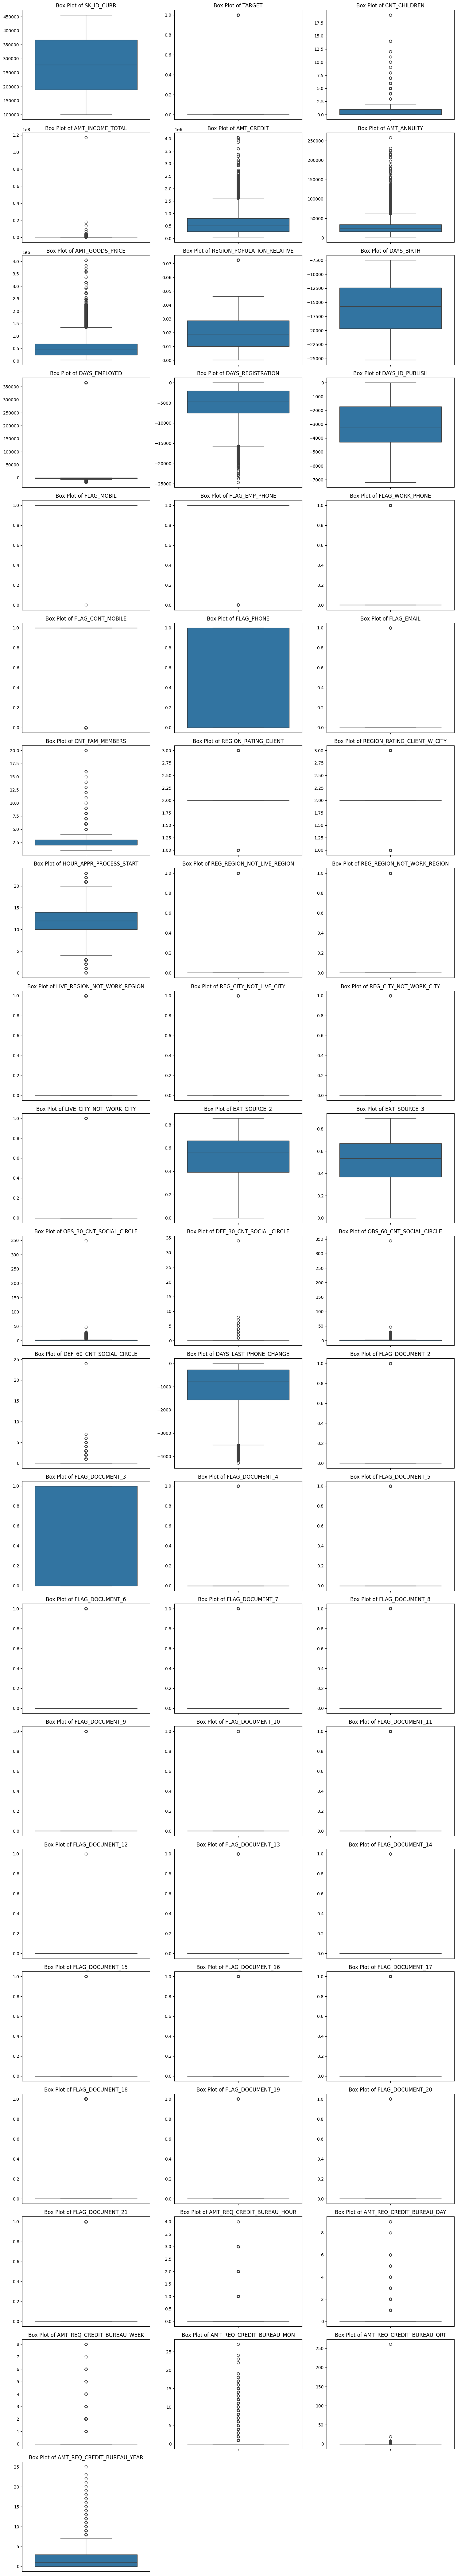

In [51]:
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

num_plots_per_row = 3
num_rows = (len(numerical_cols) + num_plots_per_row - 1) // num_plots_per_row

plt.figure(figsize=(num_plots_per_row * 5, num_rows * 4))

for i, col in enumerate(numerical_cols):
    plt.subplot(num_rows, num_plots_per_row, i + 1)
    sns.boxplot(y=df[col])
    plt.title(f'Box Plot of {col}')
    plt.ylabel('') # Remove y-label as it's just the column name
    plt.tight_layout()

plt.show()

### Outlier Analysis: IQR Method

Now, let's quantify outliers using the Interquartile Range (IQR) method. We will identify the count and percentage of outliers for each numerical column.

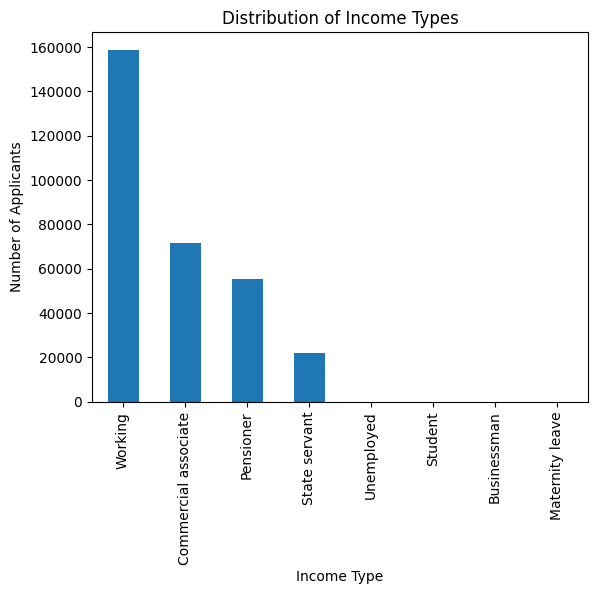

In [57]:
#### Univariate Analysis

### Pick one variable and understand the counts/ group by sums/ plot bar charts/ distributions  - Employee distrbution -> Salaried class are the most applicants in a loan setting

### Salaried class Employees are the ones with highest loan rejections


# Example: Analyzing 'NAME_INCOME_TYPE' as suggested by the comments
df['NAME_INCOME_TYPE'].value_counts().plot.bar()
plt.title('Distribution of Income Types')
plt.xlabel('Income Type')
plt.ylabel('Number of Applicants')
plt.show()

In [58]:
### categorical variables

###Frequency charts - BoX


### Frequency Charts for Categorical Variables

Let's visualize the distribution of each categorical variable using count plots. This will help us understand the frequency of each unique category within these columns.

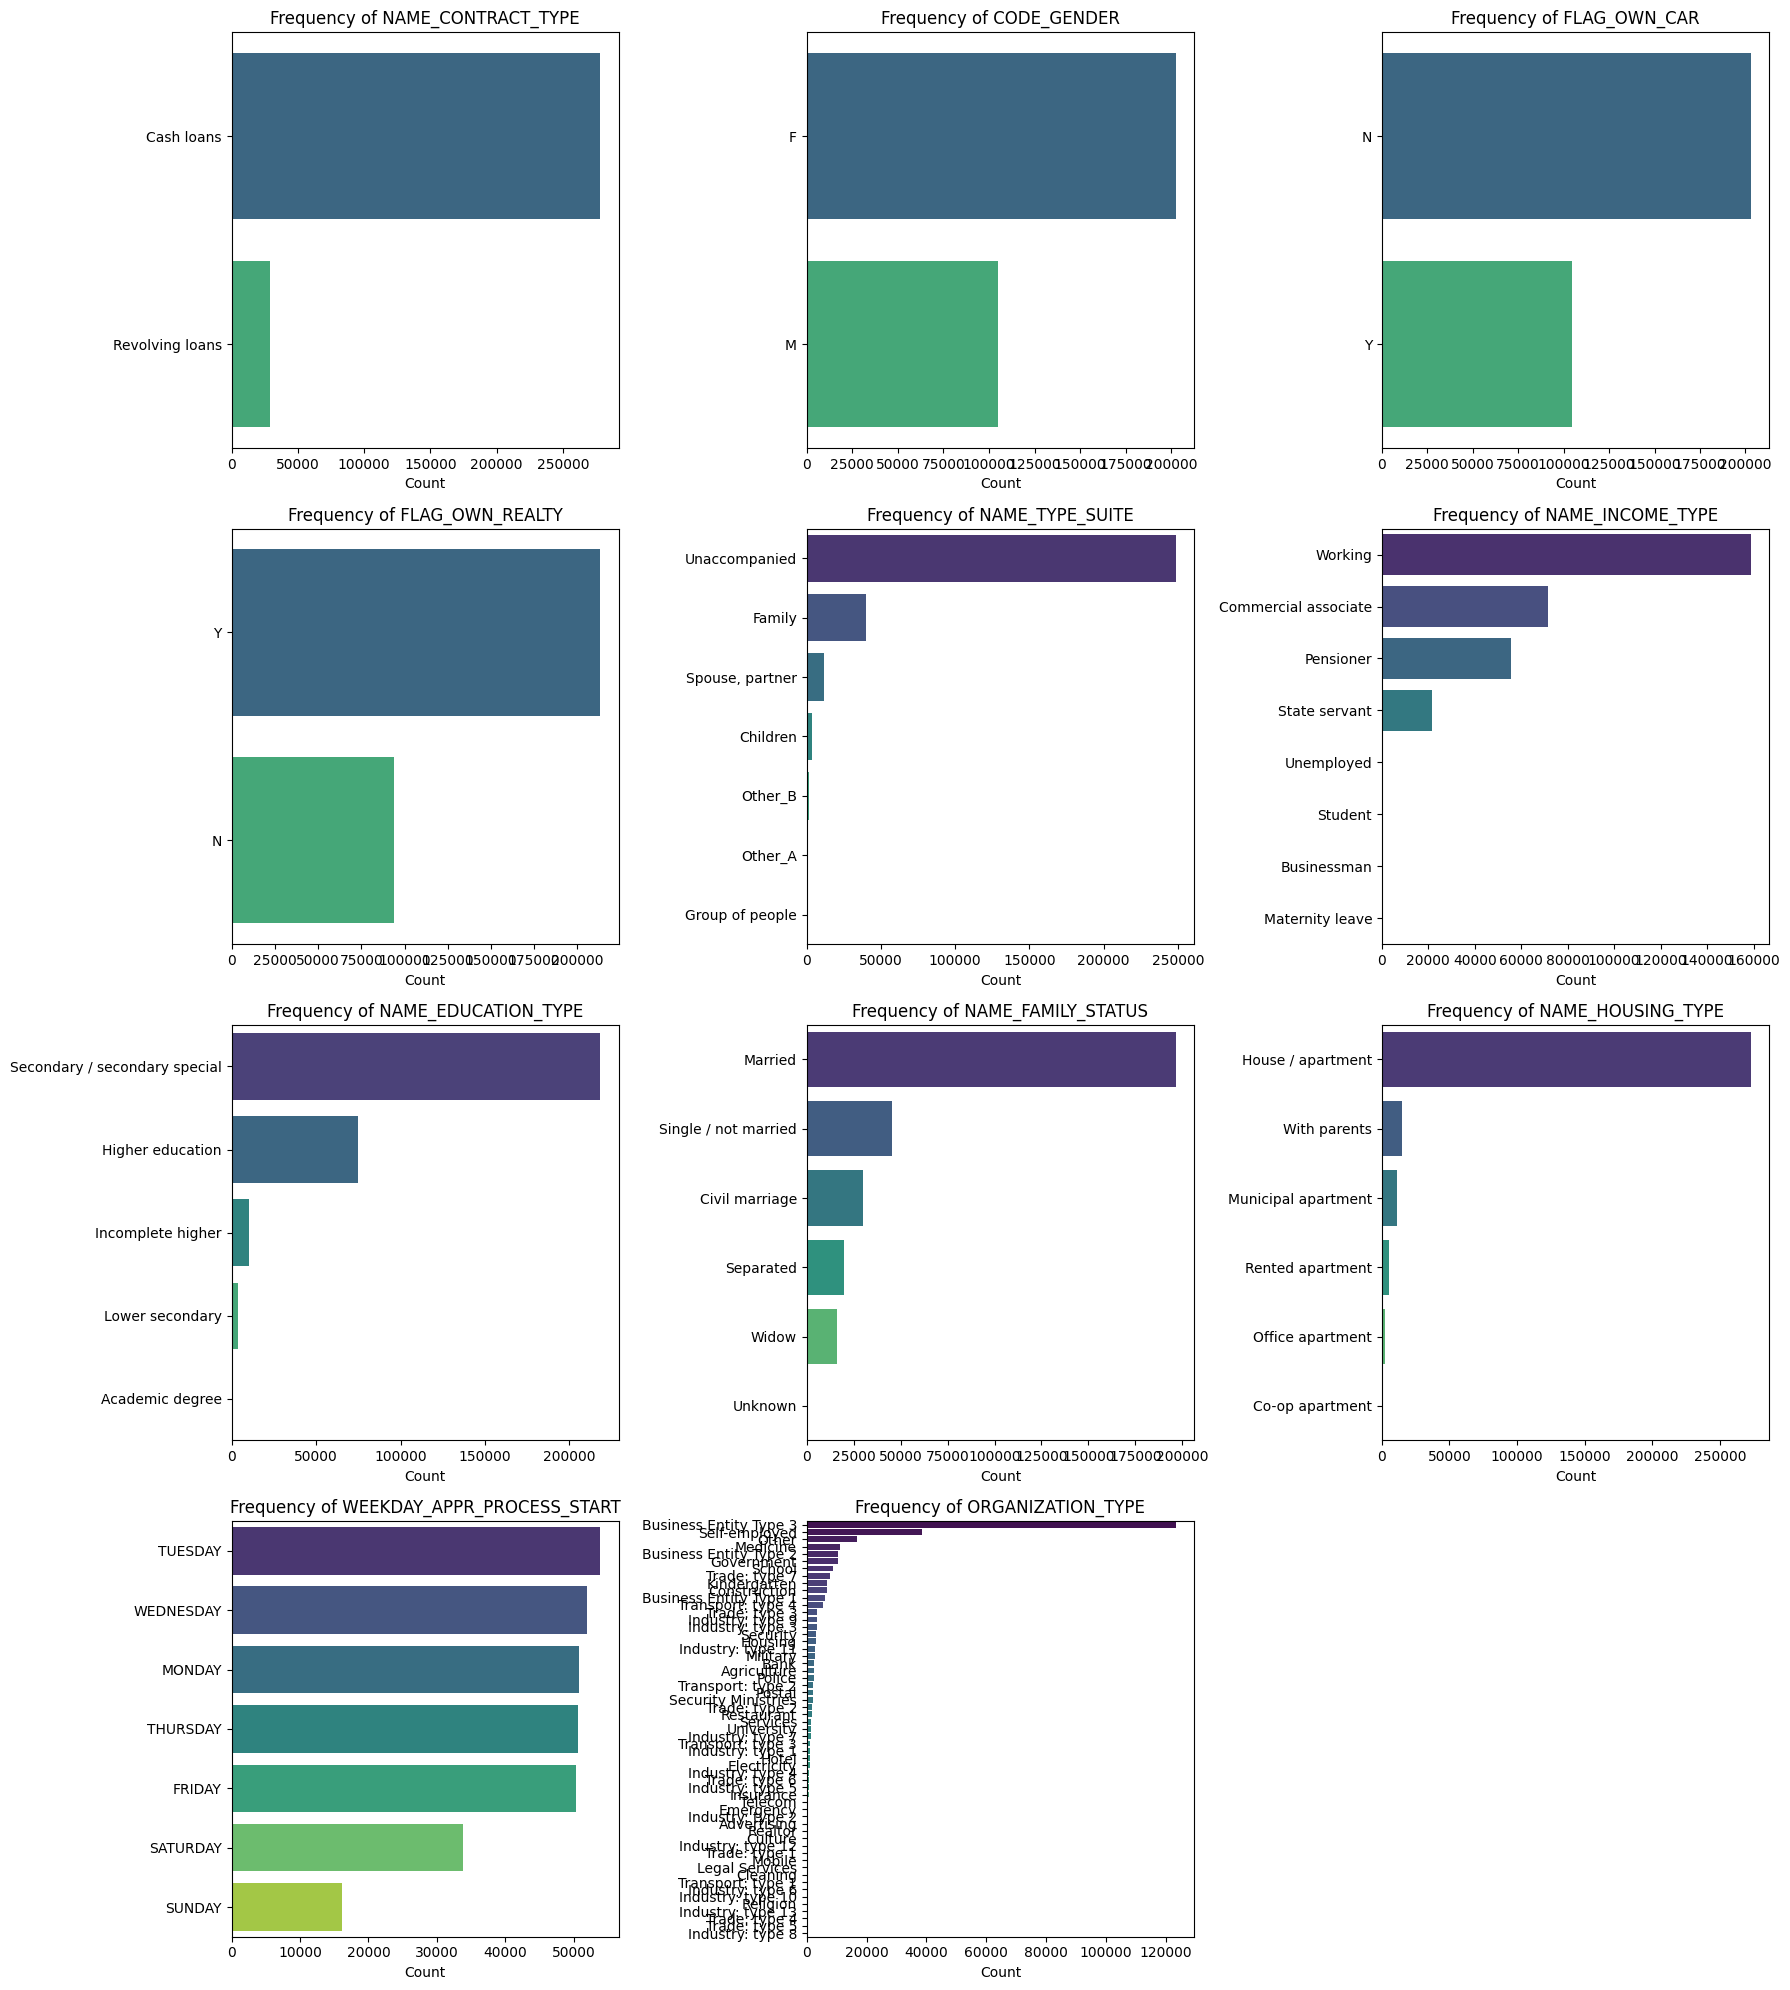

In [59]:
object_cols = df.select_dtypes(include='object').columns

# Set up the matplotlib figure and axes dynamically
num_plots = len(object_cols)
num_cols_per_row = 3 # Adjust as needed
num_rows = (num_plots + num_cols_per_row - 1) // num_cols_per_row

plt.figure(figsize=(num_cols_per_row * 6, num_rows * 5))

for i, col in enumerate(object_cols):
    plt.subplot(num_rows, num_cols_per_row, i + 1)
    sns.countplot(y=df[col], order=df[col].value_counts().index, palette='viridis')
    plt.title(f'Frequency of {col}')
    plt.xlabel('Count')
    plt.ylabel('') # Column name is in the title
    plt.tight_layout()

plt.show()


Original 'AMT_INCOME_TOTAL' head:
0    202500.0
1    270000.0
2     67500.0
3    135000.0
4    121500.0
Name: AMT_INCOME_TOTAL, dtype: float64

Binned 'AMT_INCOME_TOTAL_Binned' head:
0    200K-300K
1    200K-300K
2        <100K
3    100K-200K
4    100K-200K
Name: AMT_INCOME_TOTAL_Binned, dtype: category
Categories (6, object): ['<100K' < '100K-200K' < '200K-300K' < '300K-500K' < '500K-1M' < '>1M']


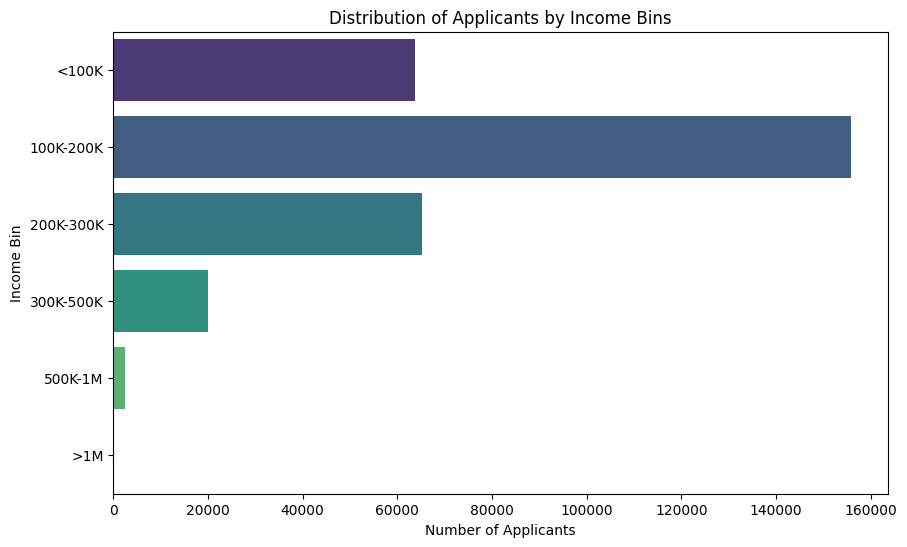

In [61]:
### Some variables like Income, Credit History etc would be better to be analysed using bins - create 10/15 bins for this

# Example for 'AMT_INCOME_TOTAL'
# Define appropriate bins and labels for income
bins = [0, 100000, 200000, 300000, 500000, 1000000, np.inf] # Using numpy.inf for the upper bound
labels = ['<100K', '100K-200K', '200K-300K', '300K-500K', '500K-1M', '>1M']

# Create a new binned column for income total
df['AMT_INCOME_TOTAL_Binned'] = pd.cut(df['AMT_INCOME_TOTAL'], bins=bins, labels=labels, right=False)

print("Original 'AMT_INCOME_TOTAL' head:")
print(df['AMT_INCOME_TOTAL'].head())
print("\nBinned 'AMT_INCOME_TOTAL_Binned' head:")
print(df['AMT_INCOME_TOTAL_Binned'].head())

# You can now analyze the distribution of this binned column
plt.figure(figsize=(10, 6))
sns.countplot(y=df['AMT_INCOME_TOTAL_Binned'], order=labels, palette='viridis')
plt.title('Distribution of Applicants by Income Bins')
plt.xlabel('Number of Applicants')
plt.ylabel('Income Bin')
plt.show()

In [ ]:
### Class Imbalance

###target Variable - Count- > What is the ratio of this

Distribution of TARGET variable:
TARGET
0    282686
1     24825
Name: count, dtype: int64

Percentage distribution of TARGET variable:
TARGET
0    91.927118
1     8.072882
Name: proportion, dtype: float64


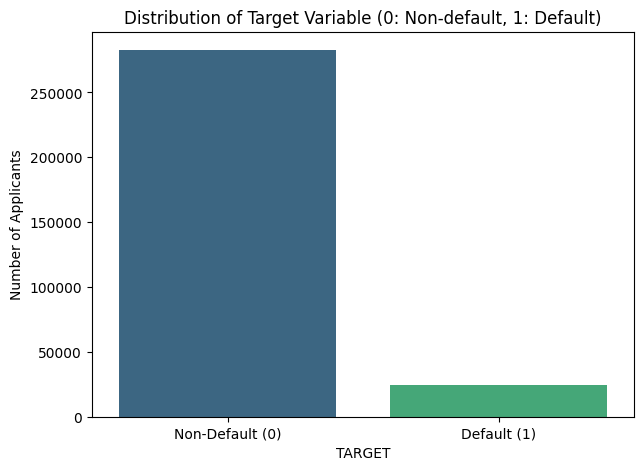


Interpretation: The dataset exhibits class imbalance, with significantly fewer instances of defaulted loans (TARGET=1) compared to non-defaulted loans (TARGET=0).


In [62]:
# Calculate the count of each class in the 'TARGET' variable
target_counts = df['TARGET'].value_counts()

# Calculate the percentage of each class
target_percentages = df['TARGET'].value_counts(normalize=True) * 100

print("Distribution of TARGET variable:")
print(target_counts)
print("\nPercentage distribution of TARGET variable:")
print(target_percentages)

# Visualize the class distribution
plt.figure(figsize=(7, 5))
sns.barplot(x=target_counts.index, y=target_counts.values, palette='viridis')
plt.title('Distribution of Target Variable (0: Non-default, 1: Default)')
plt.xlabel('TARGET')
plt.ylabel('Number of Applicants')
plt.xticks(ticks=[0, 1], labels=['Non-Default (0)', 'Default (1)'])
plt.show()

print("\nInterpretation: The dataset exhibits class imbalance, with significantly fewer instances of defaulted loans (TARGET=1) compared to non-defaulted loans (TARGET=0).")

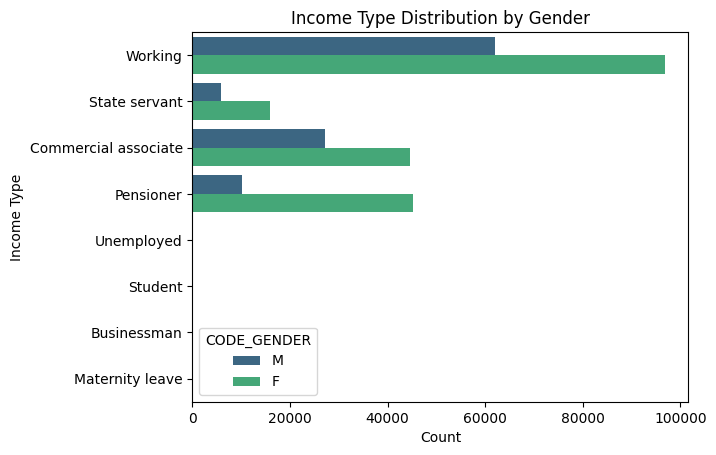

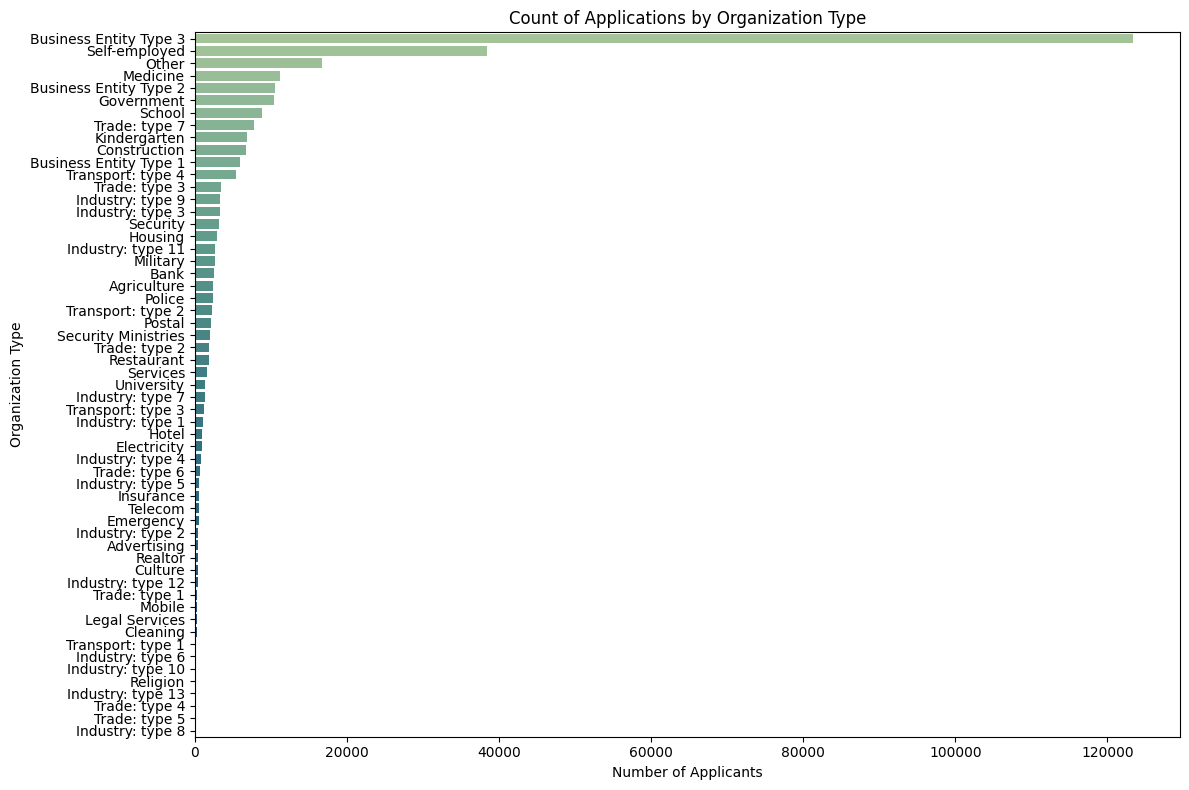

In [66]:
#### multivariate Analysis

### target with AMT_credit , Employee type, occupation type -> Bar plot hue - Stacked bar plot, Scatter Plots
### correlation multiple variables

# The previous 'plot' function was not defined. Using seaborn.countplot for multivariate analysis.
# This will plot the distribution of 'NAME_INCOME_TYPE' (Income Type) and differentiate by 'CODE_GENDER' (code_gender).
sns.countplot(data=df, y='NAME_INCOME_TYPE', hue='CODE_GENDER', palette='viridis')
plt.title('Income Type Distribution by Gender')
plt.xlabel('Count')
plt.ylabel('Income Type')
plt.show()


### Count the applications based on organization type
# This can be done using a countplot similar to the above example

###  Distribution of goods price with contract type


# heatmap - corr()

### Which the 10 most correlated variables

## Scatter plots with annuity and credit amount

### use subplots wherever necessary

## study Education type, occupation type, Assets

### Create more columns -> Combining assets


### family Status vs credit amount

plt.figure(figsize=(12, 8))
sns.countplot(y=df['ORGANIZATION_TYPE'], order=df['ORGANIZATION_TYPE'].value_counts().index, palette='crest')
plt.title('Count of Applications by Organization Type')
plt.xlabel('Number of Applicants')
plt.ylabel('Organization Type')
plt.tight_layout()
plt.show()

In [67]:
# Merge df and df2 (previous application data) on SK_ID_CURR
# Using a left merge to keep all records from the main application dataframe (df)
df_merged = pd.merge(df, df2, on='SK_ID_CURR', how='left', suffixes=('_APP', '_PREV'))

print(f"Shape of original df: {df.shape}")
print(f"Shape of previous application df2: {df2.shape}")
print(f"Shape of merged dataframe: {df_merged.shape}")

display(df_merged.head())

Shape of original df: (307511, 73)
Shape of previous application df2: (1670214, 26)
Shape of merged dataframe: (1430155, 98)


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE_APP,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT_APP,AMT_ANNUITY_APP,...,NAME_CLIENT_TYPE,NAME_GOODS_CATEGORY,NAME_PORTFOLIO,NAME_PRODUCT_TYPE,CHANNEL_TYPE,SELLERPLACE_AREA,NAME_SELLER_INDUSTRY,CNT_PAYMENT,NAME_YIELD_GROUP,PRODUCT_COMBINATION
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,New,Vehicles,POS,XNA,Stone,500.0,Auto technology,24.0,low_normal,POS other with interest
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,Repeater,XNA,Cash,x-sell,Credit and cash offices,-1.0,XNA,12.0,low_normal,Cash X-Sell: low
2,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,Refreshed,Furniture,POS,XNA,Stone,1400.0,Furniture,6.0,middle,POS industry with interest
3,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,Refreshed,Consumer Electronics,POS,XNA,Country-wide,200.0,Consumer electronics,12.0,middle,POS household with interest
4,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,New,Mobile,POS,XNA,Regional / Local,30.0,Connectivity,4.0,middle,POS mobile without interest


In [ ]:
### previous follow same steps -> Clean data, remove null columns, remove uncessary junk columns, fill na by logic if required, outlier analysis


### Cleaning `df_merged`: Handling Missing Values

First, let's identify and handle columns in the merged DataFrame (`df_merged`) that have a high percentage of missing values. We'll use a 30% threshold, similar to previous cleaning steps.

In [68]:
# Calculate the percentage of missing values for each column in df_merged
missing_percentages_merged = df_merged.isnull().sum() / len(df_merged) * 100

# Display missing percentages for columns with any missing values
print("Missing percentages in df_merged (columns with missing values):")
display(missing_percentages_merged[missing_percentages_merged > 0].sort_values(ascending=False))

# Identify columns to drop (e.g., more than 30% missing values)
columns_to_drop_merged = missing_percentages_merged[missing_percentages_merged > 30].index

# Drop the identified columns from the DataFrame
df_merged_cleaned = df_merged.drop(columns=columns_to_drop_merged)

print(f"\nOriginal df_merged DataFrame shape: {df_merged.shape}")
print(f"Columns dropped from df_merged: {list(columns_to_drop_merged)}")
print(f"New df_merged DataFrame shape after dropping high-null columns: {df_merged_cleaned.shape}")

df_merged = df_merged_cleaned.copy()

# Display the missing percentages for the remaining columns to confirm
print("\nMissing percentages in df_merged after cleaning:")
display(df_merged.isnull().sum() / len(df_merged) * 100)

Missing percentages in df_merged (columns with missing values):


,0
AMT_GOODS_PRICE_PREV,23.492489
AMT_ANNUITY_PREV,22.631952
CNT_PAYMENT,22.631603
EXT_SOURCE_3,17.174292
AMT_REQ_CREDIT_BUREAU_DAY,11.593988
AMT_REQ_CREDIT_BUREAU_HOUR,11.593988
AMT_REQ_CREDIT_BUREAU_WEEK,11.593988
AMT_REQ_CREDIT_BUREAU_QRT,11.593988
AMT_REQ_CREDIT_BUREAU_YEAR,11.593988
AMT_REQ_CREDIT_BUREAU_MON,11.593988



Original df_merged DataFrame shape: (1430155, 98)
Columns dropped from df_merged: []
New df_merged DataFrame shape after dropping high-null columns: (1430155, 98)

Missing percentages in df_merged after cleaning:


,0
SK_ID_CURR,0.000000
TARGET,0.000000
NAME_CONTRACT_TYPE_APP,0.000000
CODE_GENDER,0.000000
FLAG_OWN_CAR,0.000000
...,...
SELLERPLACE_AREA,1.150505
NAME_SELLER_INDUSTRY,1.150505
CNT_PAYMENT,22.631603
NAME_YIELD_GROUP,1.150505


### Cleaning `df_merged`: Handling Junk Values

Now, let's check for 'junk' values (like 'NAN', 'NaN', 'XNA', 'XAP') in the object columns of `df_merged`. We'll impute them with the mode if their percentage is <= 30%, otherwise, we'll note them for further consideration.

In [69]:
print("Handling junk values in df_merged:")

junk_values = ['NAN', 'NaN', 'XNA', 'XAP']
object_cols_merged = df_merged.select_dtypes(include='object').columns

columns_with_high_junk_merged = []

for col in object_cols_merged:
    # Identify rows with junk values
    junk_rows_mask = df_merged[col].isin(junk_values)
    junk_count = junk_rows_mask.sum()

    if junk_count > 0:
        junk_percentage = (junk_count / len(df_merged)) * 100
        print(f"Column '{col}': {junk_count} junk values found ({junk_percentage:.2f}%) - {df_merged[col].unique()}")

        if junk_percentage > 30:
            columns_with_high_junk_merged.append(col)
            print(f"  -> Column '{col}' has too many junk values (>30%) to impute.")
        else:
            # Impute with mode if junk percentage is <= 30%
            # Ensure mode is calculated from non-junk values
            mode_val = df_merged[col][~junk_rows_mask].mode()
            if not mode_val.empty: # Check if mode was found
                df_merged.loc[junk_rows_mask, col] = mode_val[0]
                print(f"  -> Imputed junk values in '{col}' with mode: '{mode_val[0]}'")
            else:
                print(f"  -> Could not determine a mode for '{col}' from non-junk values.")
    else:
        print(f"Column '{col}': No junk values found.")

print("\nUnique values in object columns after junk value handling:")
for col in object_cols_merged:
    print(f"'{col}': {df_merged[col].unique()}")

if columns_with_high_junk_merged:
    print(f"\nColumns with >30% junk values (not imputed): {columns_with_high_junk_merged}")
else:
    print("\nNo object columns had more than 30% junk values.")

Handling junk values in df_merged:
Column 'NAME_CONTRACT_TYPE_APP': No junk values found.
Column 'CODE_GENDER': No junk values found.
Column 'FLAG_OWN_CAR': No junk values found.
Column 'FLAG_OWN_REALTY': No junk values found.
Column 'NAME_TYPE_SUITE': No junk values found.
Column 'NAME_INCOME_TYPE': No junk values found.
Column 'NAME_EDUCATION_TYPE': No junk values found.
Column 'NAME_FAMILY_STATUS': No junk values found.
Column 'NAME_HOUSING_TYPE': No junk values found.
Column 'WEEKDAY_APPR_PROCESS_START_APP': No junk values found.
Column 'ORGANIZATION_TYPE': No junk values found.
Column 'NAME_CONTRACT_TYPE_PREV': 313 junk values found (0.02%) - ['Consumer loans' 'Cash loans' 'Revolving loans' nan 'XNA']
  -> Imputed junk values in 'NAME_CONTRACT_TYPE_PREV' with mode: 'Cash loans'
Column 'WEEKDAY_APPR_PROCESS_START_PREV': No junk values found.
Column 'FLAG_LAST_APPL_PER_CONTRACT': No junk values found.
Column 'NAME_CASH_LOAN_PURPOSE': 1354288 junk values found (94.70%) - ['XAP' 'XNA'

In [ ]:
## Purpose of previous laon , contract status with previopsu loan

### Analysis of Previous Loan Purpose (`NAME_CASH_LOAN_PURPOSE`)

As noted in the previous cleaning step, the `NAME_CASH_LOAN_PURPOSE` column contains a very high percentage of 'junk' values (XAP, XNA, NaN). We will analyze the distribution of the actual, meaningful loan purposes.

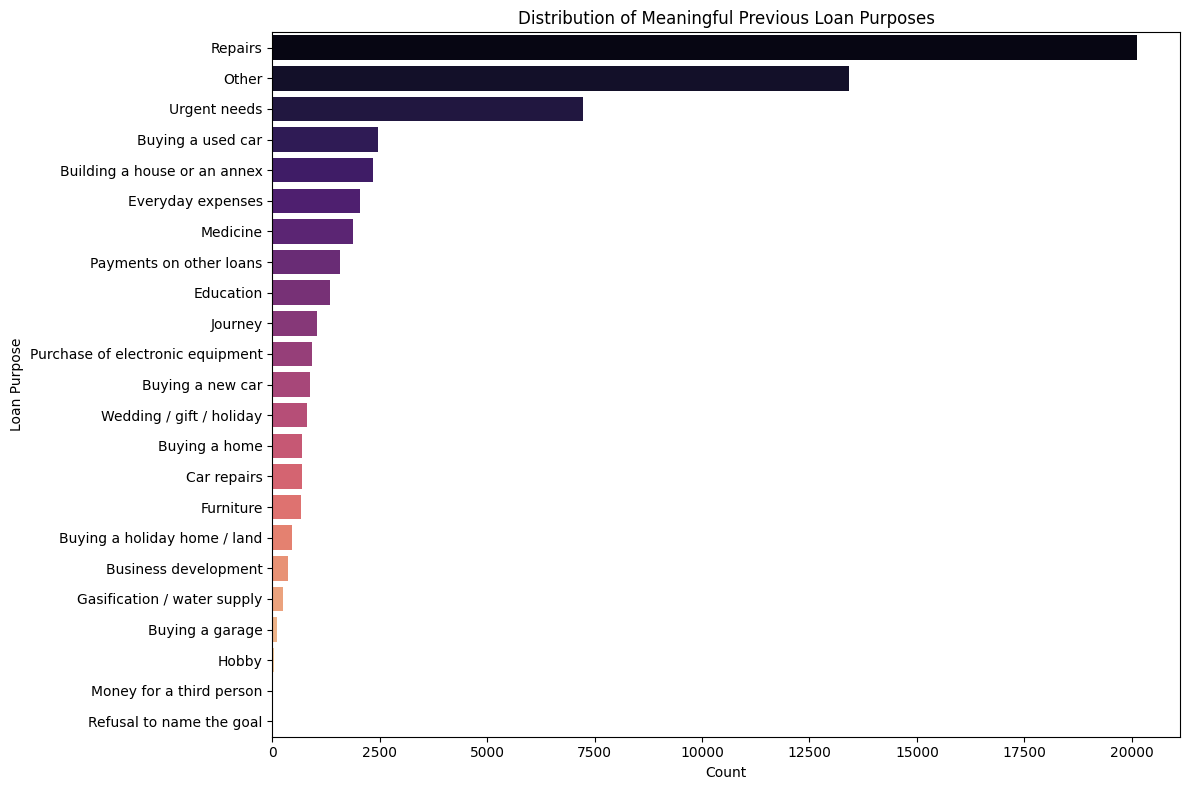


Percentage of junk/unspecified values in 'NAME_CASH_LOAN_PURPOSE': 94.70%


In [70]:
junk_values = ['NAN', 'NaN', 'XNA', 'XAP']

# Filter out junk values for analysis
meaningful_purposes = df_merged[~df_merged['NAME_CASH_LOAN_PURPOSE'].isin(junk_values)]['NAME_CASH_LOAN_PURPOSE']

plt.figure(figsize=(12, 8))
sns.countplot(y=meaningful_purposes, order=meaningful_purposes.value_counts().index, palette='magma')
plt.title('Distribution of Meaningful Previous Loan Purposes')
plt.xlabel('Count')
plt.ylabel('Loan Purpose')
plt.tight_layout()
plt.show()

# Also show the percentage of junk values again for context
junk_count_purpose = df_merged['NAME_CASH_LOAN_PURPOSE'].isin(junk_values).sum()
junk_percentage_purpose = (junk_count_purpose / len(df_merged)) * 100
print(f"\nPercentage of junk/unspecified values in 'NAME_CASH_LOAN_PURPOSE': {junk_percentage_purpose:.2f}%")

### Analysis of Previous Loan Contract Status (`NAME_CONTRACT_STATUS`)

Next, let's examine the distribution of statuses for previous loan contracts.

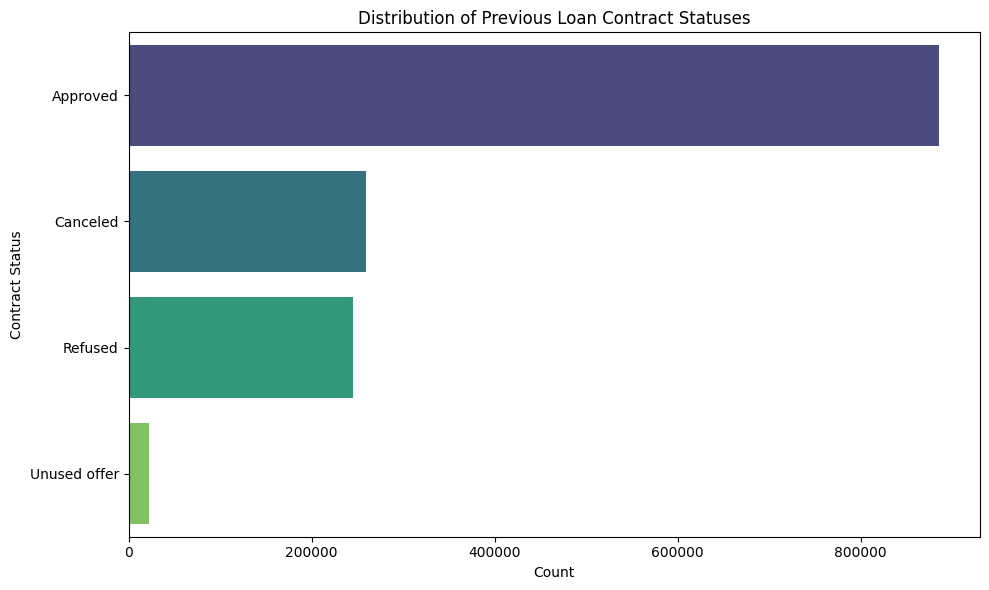

Value Counts for NAME_CONTRACT_STATUS:
NAME_CONTRACT_STATUS
Approved        886099
Canceled        259441
Refused         245390
Unused offer     22771
NaN              16454
Name: count, dtype: int64


In [71]:
plt.figure(figsize=(10, 6))
sns.countplot(y=df_merged['NAME_CONTRACT_STATUS'], order=df_merged['NAME_CONTRACT_STATUS'].value_counts().index, palette='viridis')
plt.title('Distribution of Previous Loan Contract Statuses')
plt.xlabel('Count')
plt.ylabel('Contract Status')
plt.tight_layout()
plt.show()

print("Value Counts for NAME_CONTRACT_STATUS:")
print(df_merged['NAME_CONTRACT_STATUS'].value_counts(dropna=False)) # Include NaN counts

### Relationship between Previous Contract Status and Target Variable

Let's see how the status of previous applications relates to the likelihood of defaulting on the current loan (`TARGET`).

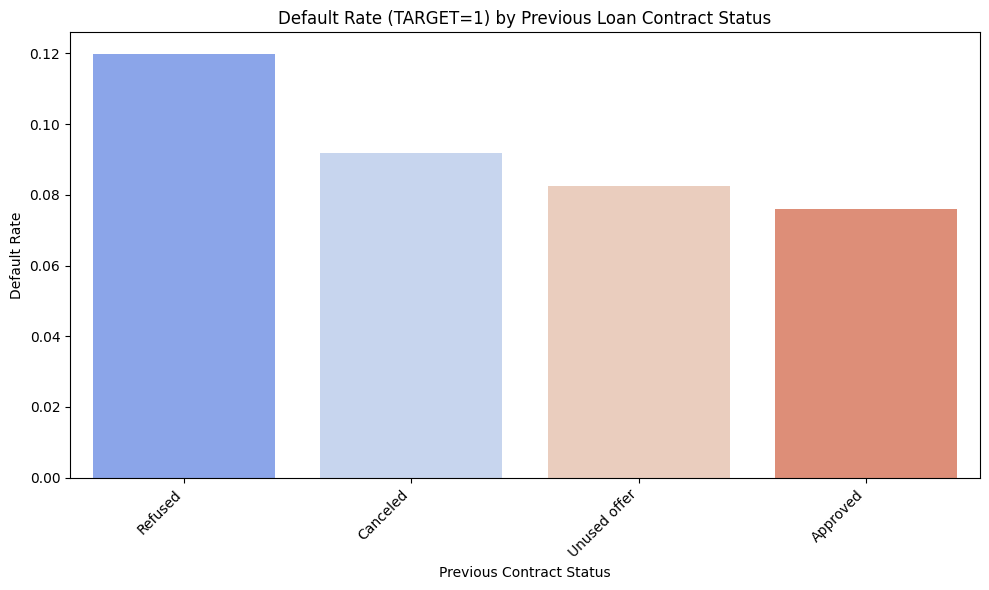

Default Rate by Previous Loan Contract Status:
NAME_CONTRACT_STATUS
Refused         0.119964
Canceled        0.091736
Unused offer    0.082517
Approved        0.075887
Name: TARGET, dtype: float64


In [72]:
# Calculate the default rate for each previous contract status
default_rate_by_status = df_merged.groupby('NAME_CONTRACT_STATUS')['TARGET'].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=default_rate_by_status.index, y=default_rate_by_status.values, palette='coolwarm')
plt.title('Default Rate (TARGET=1) by Previous Loan Contract Status')
plt.xlabel('Previous Contract Status')
plt.ylabel('Default Rate')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("Default Rate by Previous Loan Contract Status:")
print(default_rate_by_status)

In [ ]:
### Summary - Recommendations, Trends, Insights imp for the business
